Loading data
Loaded 8,020 rows * 20 cols
date rnage 2008-02-12 --> 2016-09-17
Wells : <ArrowStringArray>
['15/9-F-12', '15/9-F-14', '15/9-F-11', '15/9-F-15 D', '15/9-F-1 C',
 '15/9-F-5']
Length: 6, dtype: str
	Wells Found: 
['15/9-F-12', '15/9-F-14', '15/9-F-11', '15/9-F-15 D', '15/9-F-1 C', '15/9-F-5']

Generating Plot 1: Raw daily production decline...


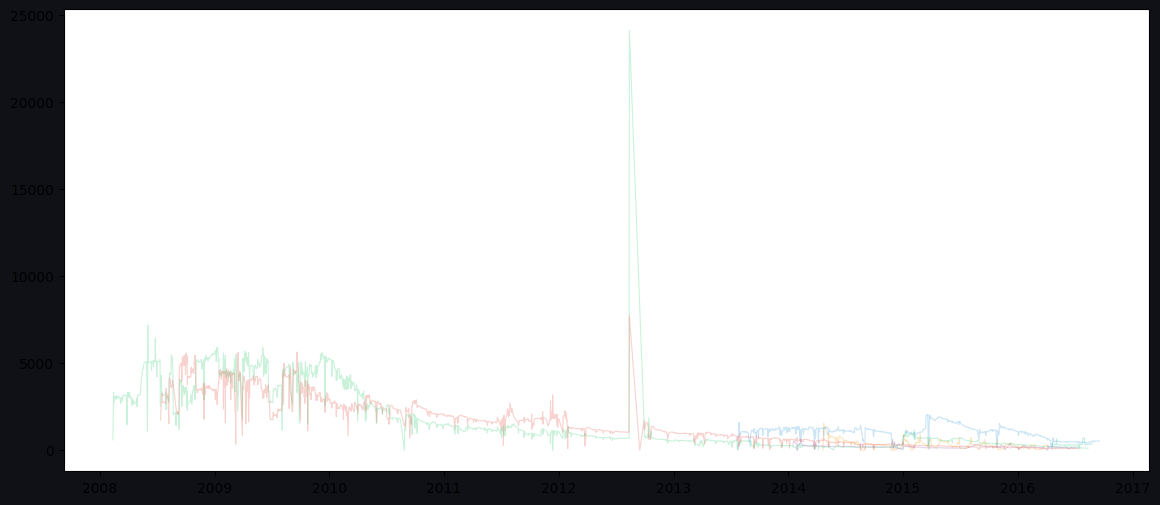

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os


WELL_COLOURS = {
    '15/9-F-1 C':   '#f39c12',   # amber
    '15/9-F-11':    '#3498db',   # blue
    '15/9-F-12':    '#2ecc71',   # green   
    '15/9-F-14':    '#e74c3c',   # red
    '15/9-F-15 D':  '#9b59b6',   # purple
    '15/9-F-5':     '#1abc9c',   # teal
}
BG    = '#0f1117'   


print("Loading data")
df = pd.read_parquet('../data/processed/cleaned.parquet')
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'])
df = df.set_index('DATEPRD').sort_index()

print(f"Loaded {df.shape[0]:,} rows * {df.shape[1]:,} cols")
print(f"date rnage {df.index.min().date()} --> {df.index.max().date()}")
print(f"Wells : {df['NPD_WELL_BORE_NAME'].unique()}")

well_groups = df.groupby('NPD_WELL_BORE_NAME')
wells = list(df['NPD_WELL_BORE_NAME'].unique())
print(f"\tWells Found: \n{wells}")


print("\nGenerating Plot 1: Raw daily production decline...")
 
fix,ax = plt.subplots(figsize=(14,6),facecolor = BG)

for well_name,well_df in well_groups:
    colour = WELL_COLOURS.get(well_name, '#ffffff')

    ax.plot(well_df.index,
            well_df['OIL_RATE_NORM'],
            color = colour,
            alpha = 0.25,
            linewidth = 0.8,
            label = '_nolegent_')